# Missense SNV Classification

Pipeline for PAH, CFTR, and hereditary cancer panel genes.


## 1. Set Up Paths, Seeds, and Target Genes


In [12]:
from pathlib import Path
import random, warnings, re
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(r"c:\Users\Umut\Desktop\MissenseProject\missense_code_mixed")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLINVAR_VCF = PROJECT_ROOT / "clinvar_20260218.vcf"
REF_FASTA = PROJECT_ROOT / "Homo_sapiens.GRCh38.dna.primary_assembly.fa"
PROTEIN_FASTA = PROJECT_ROOT / "idmapping_2026_03_16.fasta"
VEP_TSV = PROCESSED_DIR / "vep_results.tsv"

RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

TARGET_GENES = ["PAH","CFTR","BRCA1","BRCA2","PALB2","MLH1","MSH2","MSH6","PMS2","EPCAM","TP53","APC","PTEN","CDH1"]
HERED_CANCER_GENES = ["BRCA1","BRCA2","PALB2","MLH1","MSH2","MSH6","PMS2","EPCAM","TP53","APC","PTEN","CDH1"]
print("Setup complete.")


Setup complete.


## 2. Load ClinVar VCF

Pure-Python VCF parser.


In [18]:
if not CLINVAR_VCF.exists():
    raise FileNotFoundError(f"Missing ClinVar VCF at {CLINVAR_VCF}")

def parse_info(info_str):
    d = {}
    for item in info_str.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            d[k] = v
        else:
            d[item] = True
    return d

records = []
with open(CLINVAR_VCF, "r", encoding="utf-8") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        parts = line.rstrip("\n").split("\t", 8)
        if len(parts) < 8:
            continue
        chrom, pos, vid, ref, alt, qual, filt, info_str = parts[:8]
        info = parse_info(info_str)
        geneinfo = info.get("GENEINFO", "")
        gene_symbols = [p.split(":")[0] for p in geneinfo.split("|")] if geneinfo else []
        mc = info.get("MC", "")
        mc_terms = [item.split("|")[1] if "|" in item else item for item in mc.split(",")] if mc else []
        for a in alt.split(","):
            records.append({
                "Chromosome": chrom, "PositionVCF": int(pos),
                "ReferenceAllele": ref, "AlternateAllele": a,
                "VariationID": vid, "GeneSymbols": gene_symbols,
                "MolecularConsequence": mc_terms,
                "ReviewStatus": info.get("CLNREVSTAT", ""),
                "ClinicalSignificance": info.get("CLNSIG", ""),
                "VariantType": info.get("CLNVC", ""),
                "CLNHGVS": info.get("CLNHGVS", ""),
            })
clinvar_df = pd.DataFrame.from_records(records)
print(f"Loaded {len(clinvar_df):,} ClinVar records")
clinvar_df.head()


Loaded 4,352,930 ClinVar records


,Chromosome,PositionVCF,ReferenceAllele,AlternateAllele,VariationID,GeneSymbols,MolecularConsequence,ReviewStatus,ClinicalSignificance,VariantType,CLNHGVS
0,1,66926,AG,A,3385321,[OR4F5],[intron_variant],"criteria_provided,_single_submitter",Uncertain_significance,Deletion,NC_000001.11:g.66927del
1,1,69134,A,G,2205837,[OR4F5],[missense_variant],"criteria_provided,_single_submitter",Likely_benign,single_nucleotide_variant,NC_000001.11:g.69134A>G
2,1,69241,C,T,4562067,[OR4F5],[missense_variant],"criteria_provided,_single_submitter",Uncertain_significance,single_nucleotide_variant,NC_000001.11:g.69241C>T
3,1,69308,A,G,3925305,[OR4F5],[missense_variant],"criteria_provided,_single_submitter",Uncertain_significance,single_nucleotide_variant,NC_000001.11:g.69308A>G
4,1,69314,T,G,3205580,[OR4F5],[missense_variant],"criteria_provided,_single_submitter",Uncertain_significance,single_nucleotide_variant,NC_000001.11:g.69314T>G


## 3. Filter ClinVar for Missense SNVs and Labels


In [19]:
review_keep = ["reviewed by expert panel", "practice guideline"]
label_map = {"Benign":"Benign","Likely benign":"Benign","Likely_benign":"Benign",
             "Pathogenic":"Pathogenic","Likely pathogenic":"Pathogenic","Likely_pathogenic":"Pathogenic"}

def normalize_review(v):
    if not v: return ""
    return " ".join(str(v).replace("_"," ").replace(","," ").replace("|"," ").split()).lower()

def matches_review(v):
    t = normalize_review(v)
    return any(p in t for p in review_keep)

def has_missense(v):
    return bool(v) and any("missense" in str(t).lower() for t in v)

def has_target_gene(v):
    return bool(v) and any(g in TARGET_GENES for g in v)

def map_label(v):
    if not v: return None
    sigs = [s.replace("_"," ") for s in str(v).split("|")]
    mapped = list(set(label_map.get(s) for s in sigs if s in label_map))
    mapped = [m for m in mapped if m]
    return mapped[0] if len(mapped) == 1 else None

filtered = clinvar_df[
    clinvar_df["ReviewStatus"].apply(matches_review)
    & (clinvar_df["VariantType"] == "single_nucleotide_variant")
    & clinvar_df["MolecularConsequence"].apply(has_missense)
    & clinvar_df["GeneSymbols"].apply(has_target_gene)
].copy()

filtered["GeneSymbol"] = filtered["GeneSymbols"].apply(
    lambda gs: next((g for g in gs if g in TARGET_GENES), None))
filtered = filtered[filtered["GeneSymbol"].notna()].copy()

filtered["Label"] = filtered["ClinicalSignificance"].apply(map_label)
filtered = filtered[filtered["Label"].notna()].copy()

print(f"Filtered variants: {len(filtered)}")
filtered["Label"].value_counts(dropna=False)


Filtered variants: 1439


Label
Pathogenic    896
Benign        543
Name: count, dtype: int64

## 3a. ClinVar Filter QC


In [16]:
qc = []
qc.append({"step":"all_records","count":len(clinvar_df)})
qc.append({"step":"review_status","count":int(clinvar_df["ReviewStatus"].apply(matches_review).sum())})
qc.append({"step":"snv_type","count":int((clinvar_df["VariantType"]=="single_nucleotide_variant").sum())})
qc.append({"step":"missense","count":int(clinvar_df["MolecularConsequence"].apply(has_missense).sum())})
qc.append({"step":"target_genes","count":int(clinvar_df["GeneSymbols"].apply(has_target_gene).sum())})
qc.append({"step":"mapped_labels","count":int(clinvar_df["ClinicalSignificance"].apply(map_label).notna().sum())})
qc.append({"step":"filtered_final","count":len(filtered)})
pd.DataFrame(qc)


,step,count
0,all_records,4352930
1,review_status,21377
2,snv_type,4054532
3,missense,2474907
4,target_genes,111047
5,mapped_labels,1555440
6,filtered_final,1439


## 4. Prepare API Payload for VEP


In [7]:
vcf_df = filtered[["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele"]].rename(
    columns={"Chromosome":"CHROM","PositionVCF":"POS","ReferenceAllele":"REF","AlternateAllele":"ALT"})

vcf_path = PROCESSED_DIR / "clinvar_filtered.vcf"
with open(vcf_path, "w", encoding="utf-8") as h:
    h.write("##fileformat=VCFv4.2\n")
    h.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
    for r in vcf_df.itertuples(index=False):
        h.write(f"{r.CHROM}\t{r.POS}\t.\t{r.REF}\t{r.ALT}\t.\t.\t.\n")
print(f"Wrote {len(vcf_df)} variants to {vcf_path}")


Wrote 1439 variants to c:\Users\Umut\Desktop\MissenseProject\missense_code_mixed\data\processed\clinvar_filtered.vcf


## 5. Query Ensembl VEP REST API


In [21]:
import requests
import time
import urllib.parse

server = "https://rest.ensembl.org"
ext = "/vep/human/region"
headers = { "Content-Type" : "application/json", "Accept" : "application/json"}

# Format variants for VEP: 'chr:pos-pos:1/alternate'
api_variants = []
for _, row in filtered.iterrows():
    # Convert ClinVar formatting to VEP format
    v_id = f"{row['Chromosome']}:{row['PositionVCF']}-{row['PositionVCF']}:1/{row['AlternateAllele']}"
    api_variants.append({"id": v_id, "variant_string": v_id, "ref": row['ReferenceAllele']})

print(f"Total variants to query: {len(api_variants)}")

vep_rows = []
batch_size = 200

for i in range(0, len(api_variants), batch_size):
    batch_info = api_variants[i:i+batch_size]
    batch = [v['variant_string'] for v in batch_info]
    payload = { "variants" : batch }
    params = "?dbNSFP=SIFT_score,Polyphen2_HDIV_score,CADD_phred,REVEL_score,MetaLR_score,GERP++_RS,phyloP100way_vertebrate,phastCons100way_vertebrate"
    
    try:
        res = requests.post(server + ext + params, headers=headers, json=payload)
        res.raise_for_status()
        data = res.json()
        
        for var in data:
            v_id = var.get('input')
            if not v_id: continue
            parts = v_id.replace(':', '-', 1).replace('/', '-').split('-')
            if len(parts) >= 4:
                chrom, pos, _, alt = parts[0], parts[1], parts[2], parts[3]
                
                # Retrieve corresponding REF from original list
                ref_val = next((item['ref'] for item in batch_info if item['variant_string'] == v_id), '')
                
                row_data = {"CHROM": chrom, "POS": int(pos), "ALT": alt, "REF": ref_val}
                if 'transcript_consequences' in var:
                    csq = var['transcript_consequences'][0]
                    
                    # Extract Protein Change and amino acids over from VEP instead of ClinVar HGVS:
                    if 'amino_acids' in csq:
                        aa_change = csq['amino_acids'].split('/')
                        if len(aa_change) == 2:
                            row_data['RefAA'] = aa_change[0]
                            row_data['AltAA'] = aa_change[1]
                    if 'protein_start' in csq:
                        row_data['ProteinPosition'] = csq['protein_start']
                    
                    for key in ['sift_score', 'polyphen_score', 'cadd_phred', 'revel_score', 'meta_lr_score', 'gerp++_rs', 'phylop100way_vertebrate', 'phastcons100way_vertebrate']:
                        if key in csq:
                            row_data[key] = csq[key]
                if 'colocated_variants' in var:
                    for cv in var['colocated_variants']:
                        if 'gnomad_af' in cv:
                            row_data['gnomADe_AF'] = cv['gnomad_af']
                        if 'frequencies' in cv and alt in cv['frequencies']:
                            if 'gnomade' in cv['frequencies'][alt]:
                                row_data['gnomADe_AF'] = cv['frequencies'][alt]['gnomade']
                vep_rows.append(row_data)
    except requests.exceptions.RequestException as e:
        print(f"Error querying API: {e}")
    time.sleep(0.1) # Be kind to REST API

vep_df = pd.DataFrame(vep_rows)
print(f"VEP DataFrame: {vep_df.shape}")
if "RefAA" not in vep_df.columns: vep_df["RefAA"] = None
if "AltAA" not in vep_df.columns: vep_df["AltAA"] = None
if "ProteinPosition" not in vep_df.columns: vep_df["ProteinPosition"] = None
vep_df.head()


Total variants to query: 1439
VEP DataFrame: (1439, 14)


,CHROM,POS,ALT,REF,RefAA,AltAA,ProteinPosition,sift_score,polyphen_score,cadd_phred,revel_score,phylop100way_vertebrate,phastcons100way_vertebrate,gnomADe_AF
0,2,47403195,A,G,A,T,2.0,0,0.304,invalid_field,".,.,0.842,0.842,.,.,.",8.804,1.0,0.000170
1,2,47403198,T,G,V,L,3.0,0.18,0.003,invalid_field,".,.,0.369,0.369,.,.,.",5.668,1.0,0.000001
2,2,47403214,T,C,T,M,8.0,0.06,0.223,invalid_field,".,.,0.572,0.572,.,.,.",2.765,1.0,0.000979
3,2,47403329,G,C,H,Q,46.0,0,0.910,invalid_field,".,.,0.887,0.887,.,.,.",2.261,1.0,0.000465
4,2,47403355,A,G,R,Q,55.0,0.22,0.030,invalid_field,".,.,0.503,0.503,.,.,.",3.023,1.0,0.000012


## 6. Extract gnomAD AF from VEP


In [9]:
if "gnomADe_AF" in vep_df.columns:
    vep_df["gnomADe_AF_missing"] = vep_df["gnomADe_AF"].isna().astype(int)
    vep_df["gnomADe_AF"] = vep_df["gnomADe_AF"].fillna(0.0)
else:
    vep_df["gnomADe_AF"] = 0.0
    vep_df["gnomADe_AF_missing"] = 1
print(f"gnomAD AF coverage: {(1-vep_df['gnomADe_AF_missing'].mean())*100:.1f}%")
vep_df[["gnomADe_AF", "gnomADe_AF_missing"]].describe()


gnomAD AF coverage: 65.2%


,gnomADe_AF,gnomADe_AF_missing
count,1439.000000,1439.000000
mean,0.003493,0.348158
std,0.037664,0.476552
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000001,0.000000
75%,0.000036,1.000000
max,0.776700,1.000000


## 7. Extract Nucleotide Context from GRCh38 FASTA


In [28]:
from pyfaidx import Fasta

if not REF_FASTA.exists():
    raise FileNotFoundError(f"Missing reference FASTA at {REF_FASTA}")

print("Indexing FASTA (first run may take a few minutes)...")
fasta = Fasta(str(REF_FASTA))
print("FASTA indexed.")

fasta_contigs = set(fasta.keys())
def get_contig(chrom):
    c = str(chrom)
    if c in fasta_contigs: return c
    if f"chr{c}" in fasta_contigs: return f"chr{c}"
    if c.startswith("chr") and c[3:] in fasta_contigs: return c[3:]
    return None

WINDOW = 5; NT_BASES = list("ACGT")
nt_rows = []
for _, row in filtered.iterrows():
    chrom, pos = str(row["Chromosome"]), int(row["PositionVCF"])
    contig = get_contig(chrom)
    if not contig: continue
    sl = len(fasta[contig])
    s, e = max(0, pos-1-WINDOW), min(sl, pos+WINDOW)
    wseq = str(fasta[contig][s:e]).upper()
    gc = (wseq.count('G')+wseq.count('C'))/max(len(wseq),1)
    ci = pos-1-s
    tri = wseq[ci-1:ci+2] if 1<=ci<len(wseq)-1 else "NNN"
    
    # Store REF and ALT to ensure 1:1 merge later
    rec = {"Chromosome":chrom, "PositionVCF":pos, 
           "ReferenceAllele":row["ReferenceAllele"], "AlternateAllele":row["AlternateAllele"],
           "nt_window":wseq, "gc_content":gc, "trinuc_context":tri}
    
    for i, nt in enumerate(wseq):
        for b in NT_BASES:
            rec[f"nt_pos{i}_{b}"] = 1 if nt==b else 0
    nt_rows.append(rec)

nt_context = pd.DataFrame(nt_rows)
print(f"Nucleotide context: {nt_context.shape}")
nt_context.head()

Indexing FASTA (first run may take a few minutes)...
FASTA indexed.
Nucleotide context: (1439, 51)


,Chromosome,PositionVCF,ReferenceAllele,AlternateAllele,nt_window,gc_content,trinuc_context,nt_pos0_A,nt_pos0_C,nt_pos0_G,...,nt_pos8_G,nt_pos8_T,nt_pos9_A,nt_pos9_C,nt_pos9_G,nt_pos9_T,nt_pos10_A,nt_pos10_C,nt_pos10_G,nt_pos10_T
0,2,47403195,G,A,ACATGGCGGTG,0.636364,GGC,1,0,0,...,1,0,0,0,0,1,0,0,1,0
1,2,47403198,G,T,TGGCGGTGCAG,0.727273,GGT,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,2,47403214,C,T,GGAGACGCTGC,0.727273,ACG,0,0,1,...,0,1,0,0,1,0,0,1,0,0
3,2,47403329,C,G,GCGCACGGCGA,0.818182,ACG,0,0,1,...,0,0,0,0,1,0,1,0,0,0
4,2,47403355,G,A,CGCCCGGGAGG,0.909091,CGG,0,1,0,...,0,0,0,0,1,0,0,0,1,0


## 8. Extract Amino-Acid Context from Protein FASTA


In [29]:
from Bio import SeqIO

if not PROTEIN_FASTA.exists():
    raise FileNotFoundError(f"Missing protein FASTA at {PROTEIN_FASTA}")

protein_seqs = {}
for rec in SeqIO.parse(str(PROTEIN_FASTA), "fasta"):
    m = re.search(r"GN=(\w+)", rec.description)
    if m: protein_seqs[m.group(1)] = str(rec.seq)
print(f"Protein sequences loaded for: {sorted(protein_seqs.keys())}")

STANDARD_AA = list("ACDEFGHIKLMNPQRSTVWY")

AA_WINDOW = 5
aa_rows = []

# We now get the amino acid info from the merged features table (merged with VEP later)
# NOTE: to process this cell earlier, we will temporarily map RefAA, AltAA, ProteinPosition from our loaded vep_df
# Merge that info into `filtered` so we have it for this loop.
if 'CHROM' in vep_df.columns:
    temp_vep = vep_df[['CHROM','POS','REF','ALT','RefAA','AltAA','ProteinPosition']].copy()
    temp_vep["CHROM"] = temp_vep["CHROM"].astype(str)
    temp_vep["POS"] = temp_vep["POS"].astype(int)
    
    f_copy = filtered.copy()
    f_copy["Chromosome"] = f_copy["Chromosome"].astype(str)
    f_copy = f_copy.merge(temp_vep, left_on=["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele"], right_on=["CHROM","POS","REF","ALT"], how="left")
else:
    f_copy = filtered.copy()
    f_copy['RefAA'], f_copy['AltAA'], f_copy['ProteinPosition'] = None, None, None

for _, row in f_copy.iterrows():
    gene = row["GeneSymbol"]
    ref_aa = row.get("RefAA")
    alt_aa = row.get("AltAA")
    ppos = row.get("ProteinPosition")
    if pd.isna(ppos): 
        ppos = None
    else:
        ppos = int(ppos)
    
    rec = {"Chromosome":row["Chromosome"],"PositionVCF":row["PositionVCF"],
           "ReferenceAllele":row["ReferenceAllele"], "AlternateAllele":row["AlternateAllele"],
           "GeneSymbol":gene,"RefAA":ref_aa,"AltAA":alt_aa,"ProteinPosition":ppos}
    seq = protein_seqs.get(gene)
    if seq and ppos and 1 <= ppos <= len(seq):
        idx = ppos - 1
        s, e = max(0, idx-AA_WINDOW), min(len(seq), idx+AA_WINDOW+1)
        w = seq[s:e]
        rec["aa_window"] = w
        rec["local_hydrophobic_pct"] = sum(1 for a in w if a in "AILMFVPW")/len(w)
        rec["local_charged_pct"] = sum(1 for a in w if a in "DEKRH")/len(w)
        rec["local_polar_pct"] = sum(1 for a in w if a in "STNQ")/len(w)
        for i, aa in enumerate(w):
            for sa in STANDARD_AA:
                rec[f"aa_pos{i}_{sa}"] = 1 if aa==sa else 0
    else:
        rec.update({"aa_window":None,"local_hydrophobic_pct":None,"local_charged_pct":None,"local_polar_pct":None})
    aa_rows.append(rec)

aa_context = pd.DataFrame(aa_rows)
print(f"AA context: {aa_context.shape}")
print(f"Mapped: {aa_context['ProteinPosition'].notna().sum()}/{len(aa_context)}")
aa_context[["GeneSymbol","RefAA","AltAA","ProteinPosition","aa_window"]].head(10)

Protein sequences loaded for: ['APC', 'BRCA1', 'BRCA2', 'CDH1', 'CFTR', 'EPCAM', 'MLH1', 'MSH2', 'MSH6', 'PAH', 'PALB2', 'PMS2', 'PTEN', 'TP53']
AA context: (1439, 232)
Mapped: 1320/1439


,GeneSymbol,RefAA,AltAA,ProteinPosition,aa_window
0,MSH2,A,T,2.0,MAVQPKE
1,MSH2,V,L,3.0,MAVQPKET
2,MSH2,T,M,8.0,VQPKETLQLES
3,MSH2,H,Q,46.0,DFYTAHGEDAL
4,MSH2,R,Q,55.0,ALLAAREVFKT
5,MSH2,L,F,93.0,FVKDLLLVRQY
6,MSH2,R,H,96.0,DLLLVRQYRVE
7,MSH2,V,I,102.0,QYRVEVYKNRA
8,MSH2,R,K,106.0,EVYKNRAGNKA
9,MSH2,N,S,127.0,KASPGNLSQFE


## 9. Compute Biochemical Substitution Features


In [30]:
KD = {'A':1.8,'R':-4.5,'N':-3.5,'D':-3.5,'C':2.5,'E':-3.5,'Q':-3.5,'G':-0.4,'H':-3.2,'I':4.5,'L':3.8,'K':-3.9,'M':1.9,'F':2.8,'P':-1.6,'S':-0.8,'T':-0.7,'W':-0.9,'Y':-1.3,'V':4.2}
VOL = {'A':88.6,'R':173.4,'N':114.1,'D':111.1,'C':108.5,'E':138.4,'Q':143.8,'G':60.1,'H':153.2,'I':166.7,'L':166.7,'K':168.6,'M':162.9,'F':189.9,'P':112.7,'S':89.0,'T':116.1,'W':227.8,'Y':193.6,'V':140.0}
CHG = {'A':0,'R':1,'N':0,'D':-1,'C':0,'E':-1,'Q':0,'G':0,'H':0.1,'I':0,'L':0,'K':1,'M':0,'F':0,'P':0,'S':0,'T':0,'W':0,'Y':0,'V':0}
MW = {'A':89.1,'R':174.2,'N':132.1,'D':133.1,'C':121.2,'E':147.1,'Q':146.2,'G':75.0,'H':155.2,'I':131.2,'L':131.2,'K':146.2,'M':149.2,'F':165.2,'P':115.1,'S':105.1,'T':119.1,'W':204.2,'Y':181.2,'V':117.1}
POL = {'A':8.1,'R':10.5,'N':11.6,'D':13.0,'C':5.5,'E':12.3,'Q':10.5,'G':9.0,'H':10.4,'I':5.2,'L':4.9,'K':11.3,'M':5.7,'F':5.2,'P':8.0,'S':9.2,'T':8.6,'W':5.4,'Y':6.2,'V':5.9}

GD = {('A','R'):112,('A','N'):111,('A','D'):126,('A','C'):195,('A','E'):107,('A','Q'):91,('A','G'):60,('A','H'):86,('A','I'):94,('A','L'):96,('A','K'):106,('A','M'):84,('A','F'):113,('A','P'):27,('A','S'):99,('A','T'):58,('A','W'):148,('A','Y'):112,('A','V'):64,('R','N'):86,('R','D'):96,('R','C'):180,('R','E'):54,('R','Q'):43,('R','G'):125,('R','H'):29,('R','I'):97,('R','L'):102,('R','K'):26,('R','M'):91,('R','F'):97,('R','P'):103,('R','S'):110,('R','T'):71,('R','W'):101,('R','Y'):77,('R','V'):96,('N','D'):23,('N','C'):139,('N','E'):42,('N','Q'):46,('N','G'):80,('N','H'):68,('N','I'):149,('N','L'):153,('N','K'):94,('N','M'):142,('N','F'):158,('N','P'):91,('N','S'):46,('N','T'):65,('N','W'):174,('N','Y'):143,('N','V'):133,('D','C'):154,('D','E'):45,('D','Q'):61,('D','G'):94,('D','H'):81,('D','I'):168,('D','L'):172,('D','K'):101,('D','M'):160,('D','F'):177,('D','P'):108,('D','S'):65,('D','T'):85,('D','W'):181,('D','Y'):160,('D','V'):152,('C','E'):170,('C','Q'):154,('C','G'):159,('C','H'):174,('C','I'):198,('C','L'):198,('C','K'):202,('C','M'):196,('C','F'):205,('C','P'):169,('C','S'):112,('C','T'):149,('C','W'):215,('C','Y'):194,('C','V'):192,('E','Q'):29,('E','G'):98,('E','H'):40,('E','I'):134,('E','L'):138,('E','K'):56,('E','M'):126,('E','F'):140,('E','P'):93,('E','S'):80,('E','T'):65,('E','W'):152,('E','Y'):122,('E','V'):121,('Q','G'):87,('Q','H'):24,('Q','I'):109,('Q','L'):113,('Q','K'):53,('Q','M'):101,('Q','F'):116,('Q','P'):76,('Q','S'):68,('Q','T'):42,('Q','W'):130,('Q','Y'):99,('Q','V'):96,('G','H'):98,('G','I'):135,('G','L'):138,('G','K'):127,('G','M'):127,('G','F'):153,('G','P'):42,('G','S'):56,('G','T'):59,('G','W'):184,('G','Y'):147,('G','V'):109,('H','I'):94,('H','L'):99,('H','K'):32,('H','M'):87,('H','F'):100,('H','P'):77,('H','S'):89,('H','T'):47,('H','W'):115,('H','Y'):83,('H','V'):84,('I','L'):5,('I','K'):102,('I','M'):10,('I','F'):21,('I','P'):95,('I','S'):142,('I','T'):89,('I','W'):61,('I','Y'):33,('I','V'):29,('L','K'):107,('L','M'):15,('L','F'):22,('L','P'):98,('L','S'):145,('L','T'):92,('L','W'):61,('L','Y'):36,('L','V'):32,('K','M'):95,('K','F'):102,('K','P'):103,('K','S'):121,('K','T'):78,('K','W'):110,('K','Y'):85,('K','V'):97,('M','F'):28,('M','P'):87,('M','S'):135,('M','T'):81,('M','W'):67,('M','Y'):36,('M','V'):21,('F','P'):114,('F','S'):155,('F','T'):103,('F','W'):40,('F','Y'):22,('F','V'):50,('P','S'):74,('P','T'):38,('P','W'):147,('P','Y'):110,('P','V'):68,('S','T'):58,('S','W'):177,('S','Y'):144,('S','V'):124,('T','W'):128,('T','Y'):92,('T','V'):69,('W','Y'):37,('W','V'):88,('Y','V'):55}

def gdist(a1,a2):
    if a1==a2: return 0
    return GD.get((a1,a2), GD.get((a2,a1), np.nan))

PURINES={'A','G'}; PYRIMIDINES={'C','T'}
def is_transition(r,a): return int((r in PURINES and a in PURINES) or (r in PYRIMIDINES and a in PYRIMIDINES))

brows = []
for _, row in aa_context.iterrows():
    ra, aa = row["RefAA"], row["AltAA"]
    # Added ReferenceAllele and AlternateAllele to fix merge explosion
    rec = {"Chromosome":row["Chromosome"],"PositionVCF":row["PositionVCF"],
           "ReferenceAllele":row["ReferenceAllele"], "AlternateAllele":row["AlternateAllele"]}
    if ra and aa and ra in KD and aa in KD:
        rec["delta_hydrophobicity"] = KD[aa]-KD[ra]
        rec["delta_volume"] = VOL[aa]-VOL[ra]
        rec["delta_charge"] = CHG[aa]-CHG[ra]
        rec["delta_mw"] = MW[aa]-MW[ra]
        rec["delta_polarity"] = POL[aa]-POL[ra]
        rec["grantham_distance"] = gdist(ra, aa)
    brows.append(rec)

biochem_df = pd.DataFrame(brows)
fc = filtered[["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele"]].copy()
fc["is_transition"] = fc.apply(lambda r: is_transition(str(r["ReferenceAllele"]).upper(), str(r["AlternateAllele"]).upper()), axis=1)

# Now merge securely across all 4 keys
biochem_df = biochem_df.merge(fc[["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele","is_transition"]], 
                              on=["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele"], how="left")
print(f"Biochemical features: {biochem_df.shape}")
biochem_df.head()

Biochemical features: (1439, 11)


,Chromosome,PositionVCF,ReferenceAllele,AlternateAllele,delta_hydrophobicity,delta_volume,delta_charge,delta_mw,delta_polarity,grantham_distance,is_transition
0,2,47403195,G,A,-2.5,27.5,0.0,30.0,0.5,58.0,1
1,2,47403198,G,T,-0.4,26.7,0.0,14.1,-1.0,32.0,0
2,2,47403214,C,T,2.6,46.8,0.0,30.1,-2.9,81.0,1
3,2,47403329,C,G,-0.3,-9.4,-0.1,-9.0,0.1,24.0,0
4,2,47403355,G,A,1.0,-29.6,-1.0,-28.0,0.0,43.0,1


## 10. Assemble and Merge Feature Tables


In [31]:
features = filtered.copy()

# Merge VEP scores
if "CHROM" in vep_df.columns and "POS" in vep_df.columns:
    vep_df["CHROM"] = vep_df["CHROM"].astype(str)
    vep_df["POS"] = vep_df["POS"].astype(int)
    features["Chromosome"] = features["Chromosome"].astype(str)
    features = features.merge(vep_df, left_on=["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele"],
                              right_on=["CHROM","POS","REF","ALT"], how="left")

# We guarantee 1:1 merge by merging on all 4 original variant identifiers (Chrom, Pos, Ref, Alt)
merge_keys = ["Chromosome","PositionVCF","ReferenceAllele","AlternateAllele"]

# Merge nucleotide context
nt_merge_cols = [c for c in nt_context.columns if c not in merge_keys]
features = features.merge(nt_context, on=merge_keys, how="left")

# Merge AA context
aa_merge = aa_context.drop(columns=["GeneSymbol", "RefAA", "AltAA", "ProteinPosition"], errors="ignore")
features = features.merge(aa_merge, on=merge_keys, how="left", suffixes=("","_aa"))

# Merge biochemical
features = features.merge(biochem_df, on=merge_keys, how="left", suffixes=("","_bio"))

# Save
features.to_csv(PROCESSED_DIR / "features_merged.csv", index=False)
print(f"Merged features: {features.shape}")
features.head()

Merged features: (1439, 305)


,Chromosome,PositionVCF,ReferenceAllele,AlternateAllele,VariationID,GeneSymbols,MolecularConsequence,ReviewStatus,ClinicalSignificance,VariantType,...,aa_pos10_V,aa_pos10_W,aa_pos10_Y,delta_hydrophobicity,delta_volume,delta_charge,delta_mw,delta_polarity,grantham_distance,is_transition
0,2,47403195,G,A,41650,[MSH2],"[missense_variant, intron_variant]",reviewed_by_expert_panel,Likely_benign,single_nucleotide_variant,...,NaN,NaN,NaN,-2.5,27.5,0.0,30.0,0.5,58.0,1
1,2,47403198,G,T,630046,[MSH2],"[missense_variant, intron_variant]",reviewed_by_expert_panel,Benign,single_nucleotide_variant,...,NaN,NaN,NaN,-0.4,26.7,0.0,14.1,-1.0,32.0,0
2,2,47403214,C,T,90964,[MSH2],"[missense_variant, intron_variant]",reviewed_by_expert_panel,Benign,single_nucleotide_variant,...,0.0,0.0,0.0,2.6,46.8,0.0,30.1,-2.9,81.0,1
3,2,47403329,C,G,90654,[MSH2],"[missense_variant, intron_variant]",reviewed_by_expert_panel,Likely_benign,single_nucleotide_variant,...,0.0,0.0,0.0,-0.3,-9.4,-0.1,-9.0,0.1,24.0,0
4,2,47403355,G,A,220448,[MSH2],"[missense_variant, intron_variant]",reviewed_by_expert_panel,Likely_benign,single_nucleotide_variant,...,0.0,0.0,0.0,1.0,-29.6,-1.0,-28.0,0.0,43.0,1


## 11. Drop Genomic Address Columns


In [32]:
genomic_cols = ["Chromosome","PositionVCF","CHROM","POS","Start","Stop",
                "ReferenceAllele","AlternateAllele","REF","ALT","VariationID",
                "GeneSymbols","MolecularConsequence","ReviewStatus",
                "ClinicalSignificance","VariantType","CLNHGVS",
                "nt_window","trinuc_context","aa_window"]
features_final = features.drop(columns=[c for c in genomic_cols if c in features.columns])
print(f"Final features: {features_final.shape}")
features_final.head()


Final features: (1439, 287)


,GeneSymbol,Label,RefAA,AltAA,ProteinPosition,sift_score,polyphen_score,cadd_phred,revel_score,phylop100way_vertebrate,...,aa_pos10_V,aa_pos10_W,aa_pos10_Y,delta_hydrophobicity,delta_volume,delta_charge,delta_mw,delta_polarity,grantham_distance,is_transition
0,MSH2,Benign,A,T,2.0,0,0.304,invalid_field,".,.,0.842,0.842,.,.,.",8.804,...,NaN,NaN,NaN,-2.5,27.5,0.0,30.0,0.5,58.0,1
1,MSH2,Benign,V,L,3.0,0.18,0.003,invalid_field,".,.,0.369,0.369,.,.,.",5.668,...,NaN,NaN,NaN,-0.4,26.7,0.0,14.1,-1.0,32.0,0
2,MSH2,Benign,T,M,8.0,0.06,0.223,invalid_field,".,.,0.572,0.572,.,.,.",2.765,...,0.0,0.0,0.0,2.6,46.8,0.0,30.1,-2.9,81.0,1
3,MSH2,Benign,H,Q,46.0,0,0.910,invalid_field,".,.,0.887,0.887,.,.,.",2.261,...,0.0,0.0,0.0,-0.3,-9.4,-0.1,-9.0,0.1,24.0,0
4,MSH2,Benign,R,Q,55.0,0.22,0.030,invalid_field,".,.,0.503,0.503,.,.,.",3.023,...,0.0,0.0,0.0,1.0,-29.6,-1.0,-28.0,0.0,43.0,1


## 12. EDA & Visualization


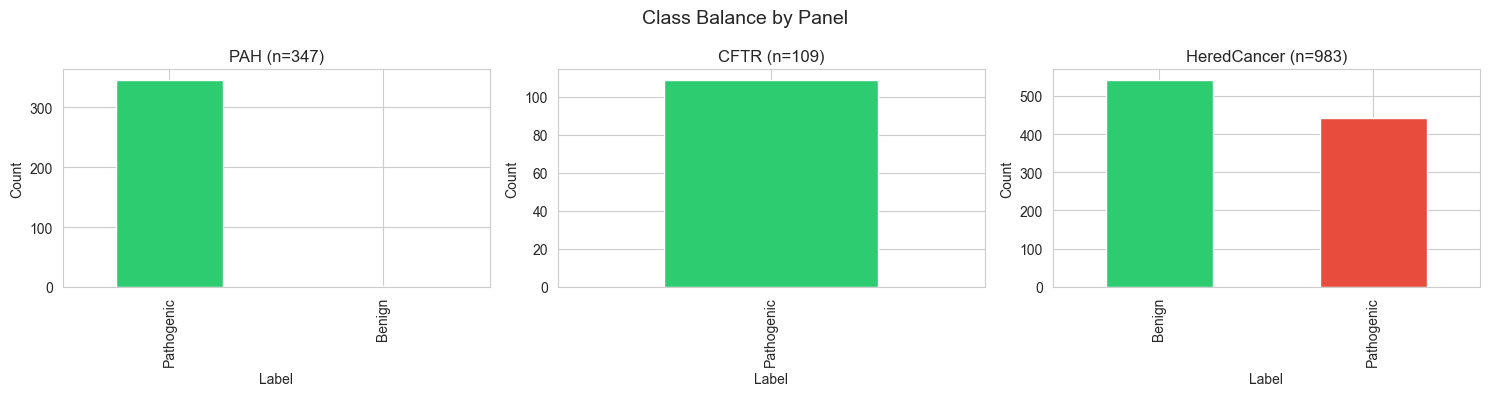

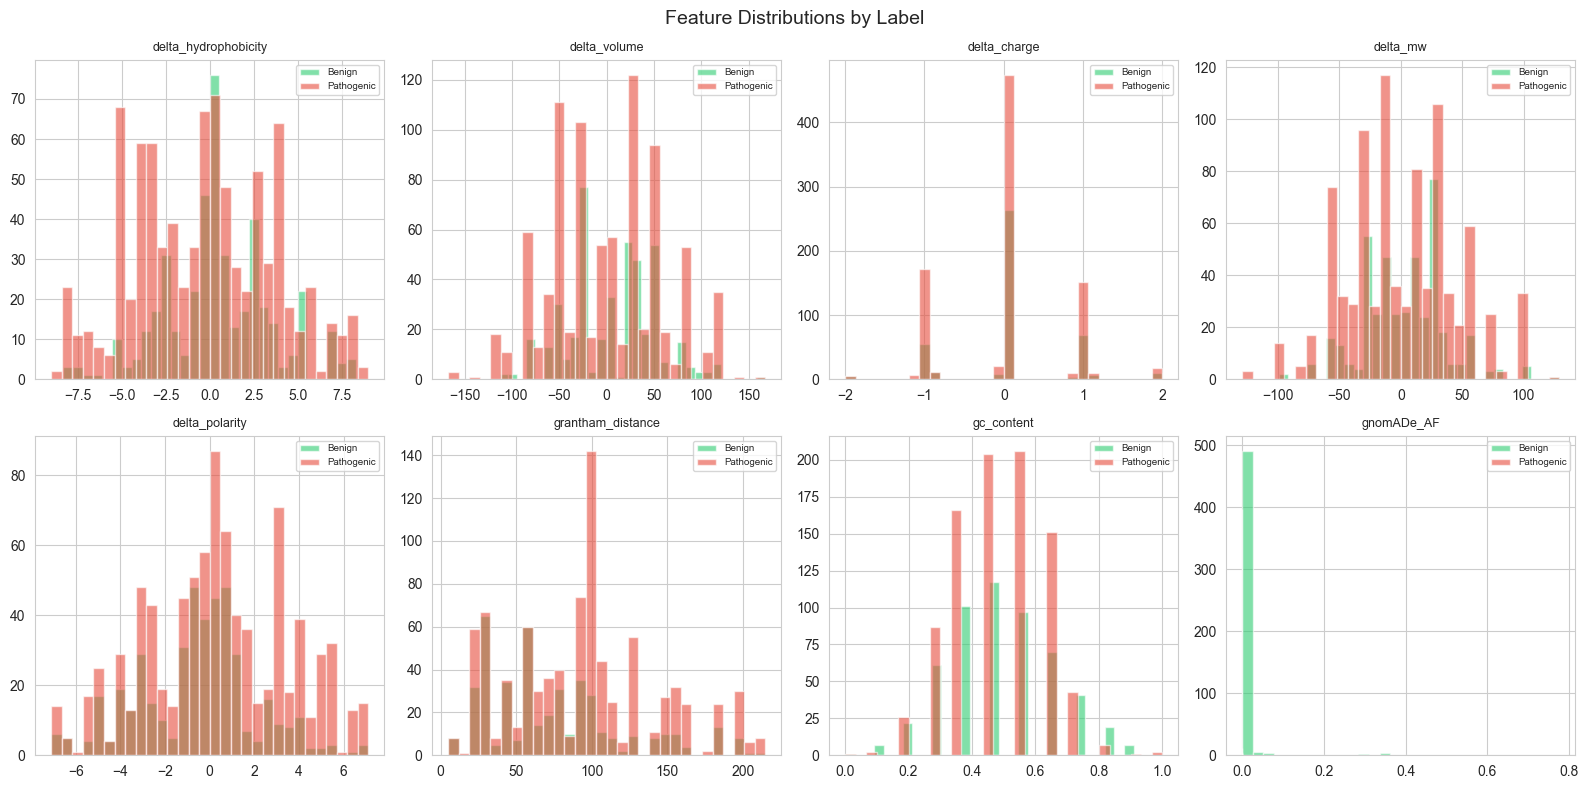

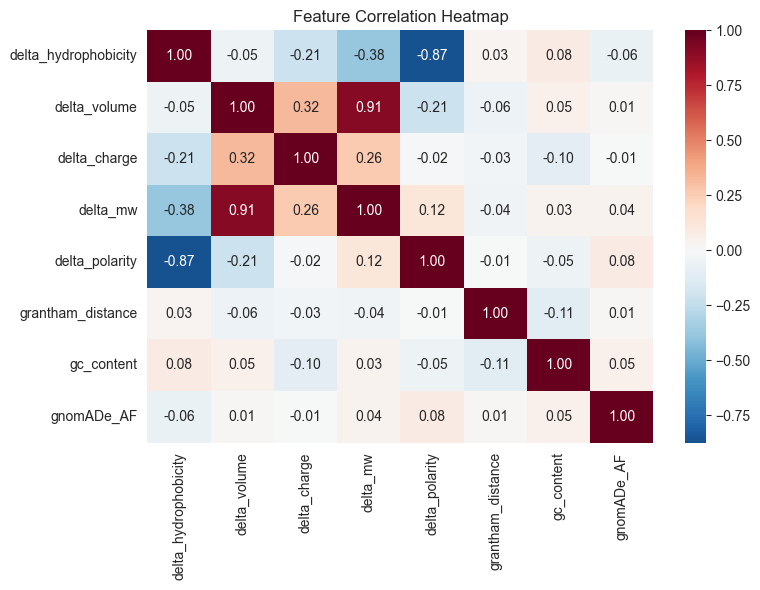

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Panel assignment
def assign_panel(gene):
    if gene == "PAH": return "PAH"
    if gene == "CFTR": return "CFTR"
    if gene in HERED_CANCER_GENES: return "HeredCancer"
    return "Other"

features_final["Panel"] = features["GeneSymbol"].apply(assign_panel)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, panel in enumerate(["PAH","CFTR","HeredCancer"]):
    sub = features_final[features_final["Panel"]==panel]
    sub["Label"].value_counts().plot.bar(ax=axes[i], color=["#2ecc71","#e74c3c"])
    axes[i].set_title(f"{panel} (n={len(sub)})")
    axes[i].set_ylabel("Count")
plt.suptitle("Class Balance by Panel", fontsize=14)
plt.tight_layout()
plt.show()

# Numeric feature distributions
num_cols = ["delta_hydrophobicity","delta_volume","delta_charge","delta_mw",
            "delta_polarity","grantham_distance","gc_content","gnomADe_AF"]
num_cols = [c for c in num_cols if c in features_final.columns]
if num_cols:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for idx, col in enumerate(num_cols[:8]):
        ax = axes[idx//4, idx%4]
        for label, color in [("Benign","#2ecc71"),("Pathogenic","#e74c3c")]:
            data = features_final[features_final["Label"]==label][col].dropna()
            ax.hist(data, bins=30, alpha=0.6, label=label, color=color)
        ax.set_title(col, fontsize=9)
        ax.legend(fontsize=7)
    plt.suptitle("Feature Distributions by Label", fontsize=14)
    plt.tight_layout()
    plt.show()

# Correlation heatmap for key numeric features
corr_cols = [c for c in num_cols if c in features_final.columns]
if len(corr_cols) > 2:
    corr = features_final[corr_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()


## 13. Preprocessing & Panel Split

Each panel gets its own independent train/test split.


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd

# Identify feature columns (drop label, panel, gene symbol)
drop_cols = ["Label", "Panel", "GeneSymbol"]
feature_cols = [c for c in features_final.columns if c not in drop_cols]

# Separate numeric and non-numeric
num_features = features_final[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Fill missing numeric with median
for col in num_features:
    features_final[col] = features_final[col].fillna(features_final[col].median())

# Encode label
le = LabelEncoder()
features_final["Label_enc"] = le.fit_transform(features_final["Label"])
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Leave-One-Panel-Out Data Setup
panels = [p for p in ["PAH", "CFTR", "HeredCancer"] if p in features_final["Panel"].values]
lopo_data = {}

for test_panel in panels:
    # Train on other panels, test on this panel
    train_df = features_final[features_final["Panel"] != test_panel]
    test_df = features_final[features_final["Panel"] == test_panel]
    
    if len(test_df) < 5 or len(train_df) < 5:
        print(f"WARNING: Not enough data for testing {test_panel}. Skipping.")
        continue
        
    X_train_raw = train_df[num_features].values
    y_train = train_df["Label_enc"].values
    
    X_test_raw = test_df[num_features].values
    y_test = test_df["Label_enc"].values

    # Scale based on training data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    lopo_data[test_panel] = {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "scaler": scaler, "feature_names": num_features,
    }
    
    print(f"Test Panel: {test_panel} | Train size: {len(X_train)} (from other panels) | Test size: {len(X_test)}")


Label encoding: {'Benign': np.int64(0), 'Pathogenic': np.int64(1)}
Test Panel: PAH | Train size: 1092 (from other panels) | Test size: 347
Test Panel: CFTR | Train size: 1330 (from other panels) | Test size: 109
Test Panel: HeredCancer | Train size: 456 (from other panels) | Test size: 983


## 14. Leave-One-Panel-Out Model Training
In this step, we train our models on 2 panels and evaluate performance on the 3rd left-out panel to test generalization.

In [36]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import builtins
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

RANDOM_SEED = 42

model_configs = {
    "RandomForest": lambda: RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED),
    "XGBoost": lambda: XGBClassifier(n_estimators=200, use_label_encoder=False, 
                                      eval_metric="logloss", random_state=RANDOM_SEED, verbosity=0),
    "LightGBM": lambda: LGBMClassifier(n_estimators=200, random_state=RANDOM_SEED, verbose=-1),
}

lopo_results = {}
lopo_best_models = {}

for test_panel, data in lopo_data.items():
    print(f"\n{'='*60}")
    print(f"Leave-One-Panel-Out Test Object: {test_panel}")
    print(f"{'='*60}")
    
    panel_results = {}
    best_f1 = -1
    best_model_name = None
    best_model = None
    
    for name, make_model in model_configs.items():
        model = make_model()
        
        # Train on remaining 2 panels
        model.fit(data["X_train"], data["y_train"])
        
        # Test on the left-out panel
        y_pred = model.predict(data["X_test"])
        
        test_f1 = f1_score(data["y_test"], y_pred)
        test_acc = accuracy_score(data["y_test"], y_pred)
        
        panel_results[name] = {
            "test_f1": test_f1, 
            "test_accuracy": test_acc, 
            "model": model,
            "y_pred": y_pred
        }
        
        print(f"  {name:15}: Valid F1 (on {test_panel}) = {test_f1:.4f}  |  Acc = {test_acc:.4f}")
        
        if test_f1 > best_f1:
            best_f1 = test_f1
            best_model_name = name
            best_model = model
            
    lopo_results[test_panel] = panel_results
    lopo_best_models[test_panel] = (best_model_name, best_model)

print("\nBest LOGO (Leave-One-Group-Out) Models per Panel:")
for panel, (name, _) in lopo_best_models.items():
    print(f"  Predicting {panel} -> Best Model: {name}")



Leave-One-Panel-Out Test Object: PAH
  RandomForest   : Valid F1 (on PAH) = 0.9956  |  Acc = 0.9914
  XGBoost        : Valid F1 (on PAH) = 1.0000  |  Acc = 1.0000
  LightGBM       : Valid F1 (on PAH) = 1.0000  |  Acc = 1.0000

Leave-One-Panel-Out Test Object: CFTR
  RandomForest   : Valid F1 (on CFTR) = 1.0000  |  Acc = 1.0000
  XGBoost        : Valid F1 (on CFTR) = 1.0000  |  Acc = 1.0000
  LightGBM       : Valid F1 (on CFTR) = 1.0000  |  Acc = 1.0000

Leave-One-Panel-Out Test Object: HeredCancer
  RandomForest   : Valid F1 (on HeredCancer) = 0.6194  |  Acc = 0.4486
  XGBoost        : Valid F1 (on HeredCancer) = 0.6194  |  Acc = 0.4486
  LightGBM       : Valid F1 (on HeredCancer) = 0.6194  |  Acc = 0.4486

Best LOGO (Leave-One-Group-Out) Models per Panel:
  Predicting PAH -> Best Model: XGBoost
  Predicting CFTR -> Best Model: RandomForest
  Predicting HeredCancer -> Best Model: RandomForest


## 15. Hyperparameter Tuning (Optuna)


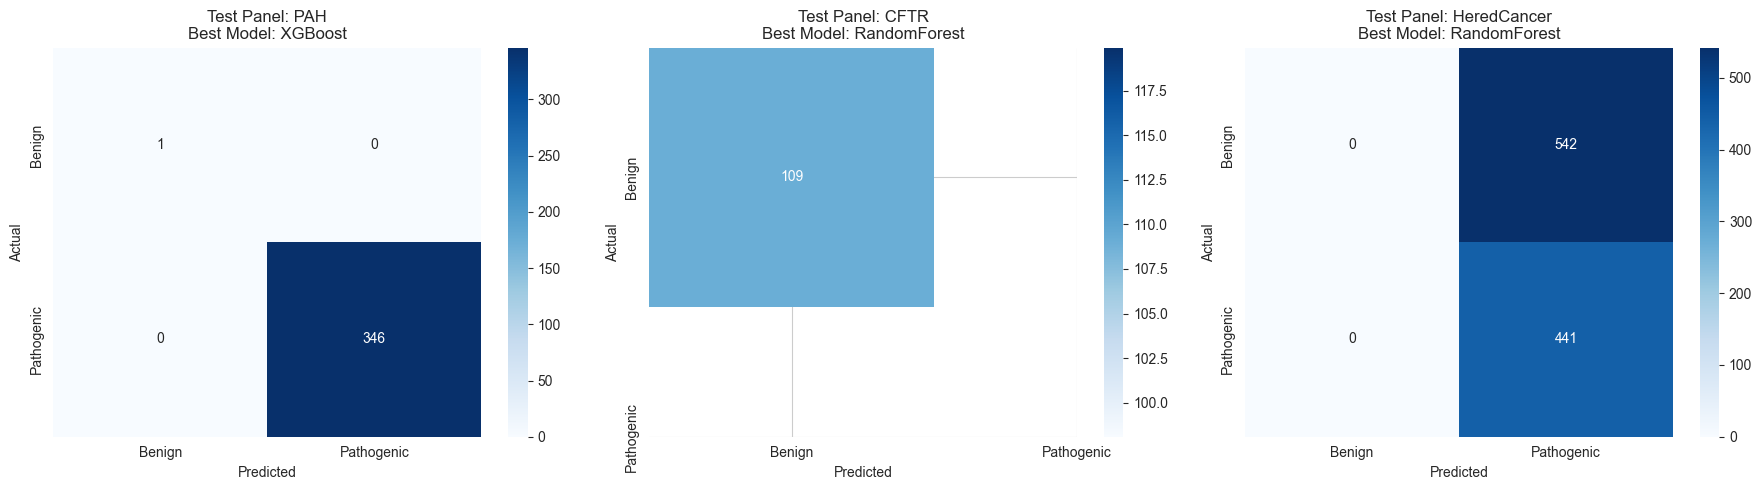


--- Detailed Metrics for Leave-One-Panel-Out ---

PAH (Left out):
  Model used   : XGBoost
  Test Accuracy: 1.0000
  Test F1 Score: 1.0000

CFTR (Left out):
  Model used   : RandomForest
  Test Accuracy: 1.0000
  Test F1 Score: 1.0000

HeredCancer (Left out):
  Model used   : RandomForest
  Test Accuracy: 0.4486
  Test F1 Score: 0.6194


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (panel, (model_name, model)) in enumerate(lopo_best_models.items()):
    ax = axes[i]
    
    # Get test data (the left-out panel)
    X_test = lopo_data[panel]["X_test"]
    y_test = lopo_data[panel]["y_test"]
    
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Pathogenic"], 
                yticklabels=["Benign", "Pathogenic"])
    ax.set_title(f"Test Panel: {panel}\nBest Model: {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    
plt.tight_layout()
plt.show()

# Print combined metrics
print("\n--- Detailed Metrics for Leave-One-Panel-Out ---")
for panel, results in lopo_results.items():
    best_name = lopo_best_models[panel][0]
    best_metrics = results[best_name]
    print(f"\n{panel} (Left out):")
    print(f"  Model used   : {best_name}")
    print(f"  Test Accuracy: {best_metrics['test_accuracy']:.4f}")
    print(f"  Test F1 Score: {best_metrics['test_f1']:.4f}")


## 16. Evaluation per Panel


In [ ]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, RocCurveDisplay)

eval_results = []

fig, axes = plt.subplots(1, len(tuned_models), figsize=(5*len(tuned_models), 4))
if len(tuned_models) == 1: axes = [axes]

for idx, (panel, (name, model)) in enumerate(tuned_models.items()):
    data = panel_data[panel]
    y_pred = model.predict(data["X_test"])
    y_prob = model.predict_proba(data["X_test"])[:, 1] if hasattr(model, "predict_proba") else y_pred

    acc = accuracy_score(data["y_test"], y_pred)
    f1 = f1_score(data["y_test"], y_pred)
    try:
        auc = roc_auc_score(data["y_test"], y_prob)
    except ValueError:
        auc = float("nan")

    eval_results.append({"Panel":panel,"Model":name,"Accuracy":acc,"F1":f1,"ROC_AUC":auc})

    print(f"\n{'='*50}")
    print(f"{panel} — {name}")
    print(f"{'='*50}")
    print(classification_report(data["y_test"], y_pred, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(data["y_test"], y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[idx].set_title(f"{panel} — {name}")
    axes[idx].set_ylabel("True"); axes[idx].set_xlabel("Predicted")

plt.suptitle("Confusion Matrices per Panel", fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
eval_df = pd.DataFrame(eval_results)
print("\n=== Summary ===")
eval_df


## 17. Feature Importance (SHAP)


In [ ]:
import shap

for panel, (name, model) in tuned_models.items():
    data = panel_data[panel]
    print(f"\n{'='*50}")
    print(f"SHAP — {panel} ({name})")
    print(f"{'='*50}")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(data["X_test"])

    # For binary classification, shap_values may be a list
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, data["X_test"],
                      feature_names=data["feature_names"],
                      show=False, max_display=20)
    plt.title(f"SHAP Summary — {panel}")
    plt.tight_layout()
    plt.show()


## 18. Conclusion & Export


In [ ]:
import pickle

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

for panel, (name, model) in tuned_models.items():
    path = MODEL_DIR / f"best_model_{panel}.pkl"
    with open(path, "wb") as f:
        pickle.dump({"model": model, "name": name,
                     "scaler": panel_data[panel]["scaler"],
                     "feature_names": panel_data[panel]["feature_names"]}, f)
    print(f"Saved {panel} model ({name}) to {path}")

# Export final feature matrix
features_final.to_csv(PROCESSED_DIR / "features_final.csv", index=False)
print(f"\nFinal feature matrix saved: {features_final.shape}")
print("\n=== DONE ===")
eval_df
